In [230]:
import pandas
import matplotlib.pyplot as plt
data = pandas.read_csv('prices_round_1_day_0.csv',sep=';')
squid_ink=data[data['product']=="SQUID_INK"]

In [ ]:
import pandas as pd

####################################################################################################
#
# THIS IS THE CODE FOR GETTING THE CHANGE IN VALUES (IF EACH VALUE IS A POSITIVE OR NEGATIVE VALUE)
#
####################################################################################################

data = pd.read_csv('prices_round_1_day_0.csv',sep=';')
ink = data[data['product']=="SQUID_INK"]
change1 = [] # array containing increasing price points
change2 = [] # array containing decreasing price points
change = [] # array containing all price points, if increasing = 1, if stable = 0, if decreasing = -1
diffArray = []
for i in range(1,10000,1):
    #curr = (ink.iloc[i]['ask_price_1'] + ink.iloc[i]['bid_price_1'])/2 # current mid price
    #past = (ink.iloc[i-1]['ask_price_1'] + ink.iloc[i-1]['bid_price_1'])/2 # past mid price
    grad = (ink.iloc[i]['ask_price_1']-ink.iloc[i-1]['ask_price_1'])/(ink.iloc[i]['timestamp']-ink.iloc[i-1]['timestamp']) # gradient of prices
    diff = (ink.iloc[i]['ask_price_1']-ink.iloc[i-1]['ask_price_1'])
    if grad < 0 :
        change2.append(1)
        change1.append(0)
        change.append(-1)
        diffArray.append(diff/2)
    elif grad > 0 :
        change1.append(1)
        change2.append(0)
        change.append(1)
        diffArray.append(diff/2)
    else :
        change1.append(0)
        change2.append(0)
        change.append(0)
        diffArray.append(0)

print(change)

positive=[] # A binary array with all the locations of the positive values
for j in range(len(change1)) :
    positive.append(squid_ink.iloc[j]['ask_price_1']*change1[j]+diffArray[j])
positive.append(0)
#print(positive)

negative = [] # A binary array with all the locations of the negative values
for k in range(len(change2)) :
    negative.append(squid_ink.iloc[k]['ask_price_1']*change2[k]+diffArray[k])
negative.append(0)
#print(negative)





[0, -1, -1, 0, 1, -1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, -1, 1, -1, 1, -1, 1, 0, 1, 0, 0, -1, 1, 0, 0, -1, 1, 0, -1, 0, 0, -1, 1, 0, 0, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 0, 1, -1, 1, 0, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, -1, 0, 0, -1, 1, -1, 1, 0, 1, 1, 0, -1, 0, 1, 1, 0, 1, -1, 0, 1, 1, -1, -1, 1, 0, 0, 1, 1, -1, 1, -1, 1, -1, 1, -1, 1, 0, -1, 1, 0, 1, -1, 0, 1, -1, -1, 1, 0, -1, -1, 1, -1, 0, -1, 0, -1, 1, 1, -1, -1, 1, 1, -1, 0, 0, 0, 1, 1, 0, -1, 1, -1, 1, -1, 0, 1, 0, 1, -1, 1, -1, 0, 1, -1, -1, 0, -1, 1, -1, -1, 1, 0, 1, -1, -1, 1, 0, -1, -1, 1, 1, -1, 1, -1, 1, -1, 1, 1, 0, 1, -1, 1, -1, -1, -1, 1, 1, -1, 1, 0, 0, 1, 0, 1, -1, 1, 0, -1, 1, -1, 1, -1, 1, 1, -1, 1, 0, 0, 0, 1, 1, -1, 1, 1, -1, 1, -1, 1, 0, 1, -1, 1, 1, 0, -1, 0, 1, 0, -1, 1, 0, 0, -1, 1, 1, 0, 1, -1, 1, 0, 0, 0, -1, -1, 1, -1, -1, 1, -1, 1, 0, -1, 1, -1, 1, -1, -1, 0, 1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, 0, -1, 1, 0, 1, 1, 0, 1, -1, 1, 0, 1, -1, -1, 1, -1, 1, -1, 0, -1, 1, -1, -1, 0, 0, -1

In [232]:
###########################################################################################
#
# THIS IS THE CODE FOR GETTING THE TREND OF THE DATA AS A WHOLE 
#
###########################################################################################

trend = []
trendNeg = []
trendPos = []

period = 5

for i in list(range(0,len(change),period)) :
    upCounter = 0
    downCounter = 0
    for j in list(range(period)) :
        if change[i+j-1] > 0 :
            upCounter = upCounter + 1
        elif change[i+j-1] < 0 :
            downCounter = downCounter + 1
    if downCounter > upCounter :
        for k in list(range(period)) :
            trend.append(-1)
            trendNeg.append(1)
            trendPos.append(0)
    elif downCounter < upCounter : 
        for k in list(range(period)) :
            trend.append(1)
            trendNeg.append(0)
            trendPos.append(1)
    else :
        for k in list(range(period)) :
            if i != 0 :
                trend.append(trend[i-1])
                trendNeg.append(trendNeg[i-1])
                trendPos.append(trendPos[i-1])
            else :
                trend.append(0)
                trendNeg.append(0)
                trendPos.append(0)

print(trend)
print(trendPos)
print(trendNeg)

[-1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -

In [233]:
###########################################################################################
#
# THIS IS THE CODE FOR GETTING THE LIVE TREND 
#
###########################################################################################
trend = []
trend.extend(change)
trendNeg = []
trendNeg.extend(change)
trendPos = []
trendPos.extend(change)
#print(trend)

period = 5

upCounter = 0
downCounter = 0
for j in range(period) :
    if change[j] > 0 :
        upCounter = upCounter + 1
    elif change[j] < 0 :
        downCounter = downCounter + 1
if downCounter > upCounter :
    for k in range(period) :
        trend[k] = -1
        trendNeg[k] = 1
        trendPos[k] = 0
elif downCounter < upCounter : 
    for k in range(period) :
        trend[k] = 1
        trendNeg[k] = 0
        trendPos[k] = 1
else :
    for k in list(range(period)) :
        trend[k] = 0
        trendNeg[k] = 0
        trendPos[k] = 0     


for i in range(period,len(change),period) :
    upCounter = 0
    downCounter = 0
    for j in range(period) :
        if change[i-j] > 0 :
            upCounter = upCounter + 1
        elif change[i-j] < 0 :
            downCounter = downCounter + 1
    if downCounter > upCounter :
        for k in range(period) :
            trend[i-k+1] = -1
            trendNeg[i-k+1] = 1
            trendPos[i-k+1] = 0
    elif downCounter < upCounter : 
        for k in range(period) :
            trend[i-k+1] = 1
            trendNeg[i-k+1] = 0
            trendPos[i-k+1] = 1
    else :
        for k in range(period) :
            if i > period-1 :
                trend[i-k+1] = trend[i-1]
                trendNeg[i-k+1] = trendNeg[i-1]
                trendPos[i-k+1] = trendPos[i-1]
            else :
                trend[i-k+1] = 0
                trendNeg[i-k+1] = 0
                trendPos[i-k+1] = 0

print(trend)
#print(trendPos)
#print(trendNeg)

[-1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 

In [234]:
###########################################################################################
#
# THIS IS THE CODE FOR GETTING THE ARROWS ON THE GRAPH
#
###########################################################################################

positiveTrend=[] # You can use this as the prices for the positive region
for j in range(len(change1)) :
    positiveTrend.append(squid_ink.iloc[j]['ask_price_1']*trendPos[j]+diffArray[j])
positiveTrend.append(0)
#print(positive)

negativeTrend = [] # And htis as the prices for the negative region
for k in range(len(change2)) :
    negativeTrend.append(squid_ink.iloc[k]['ask_price_1']*trendNeg[k]+diffArray[k])
negativeTrend.append(0)
#print(negative)


In [235]:
sar = (squid_ink.iloc[0]['ask_price_1']+squid_ink.iloc[0]['bid_price_1'])/2
af = 0.02
ep = 0 # this is the peak or trough (extreme point) for the up or down region, but i'm a bit lost on how to implement that
epPrev = 0
sarArray = []

currentRegion = []


for i in range(len(positiveTrend)) :
    if trend[i-1] < 0 :
        j = 1
        while True :
            if trend[i-j] != -1 :
                break
            else :
                j = j + 1
        for k in range(j) :
            currentRegion.append(negativeTrend[j-k])
    elif trend[i-1] > 0 : 
        j = 1
        while True :
            if trend[i-j] != 1 :
                break
            else :
                j = j + 1
        for k in range(j) :
            currentRegion.append(positiveTrend[j-k])
    ep = max(currentRegion)
    sar = sar + af * (ep - sar)
    sarArray.append(sar)

print(sarArray)



[np.float64(1969.51), np.float64(1969.5198), np.float64(1969.529404), np.float64(1969.5388159200002), np.float64(1969.5480396016), np.float64(1969.557078809568), np.float64(1969.5659372333766), np.float64(1969.5746184887091), np.float64(1969.5831261189348), np.float64(1969.5914635965562), np.float64(1969.5996343246252), np.float64(1969.6076416381327), np.float64(1969.61548880537), np.float64(1969.6231790292625), np.float64(1969.6307154486772), np.float64(1969.6381011397036), np.float64(1969.6553391169095), np.float64(1969.6822323345714), np.float64(1969.70858768788), np.float64(1969.7344159341224), np.float64(1969.75972761544), np.float64(1969.7845330631312), np.float64(1969.8088424018686), np.float64(1969.8326655538312), np.float64(1969.8560122427546), np.float64(1969.8788919978995), np.float64(1969.9013141579414), np.float64(1969.9232878747825), np.float64(1969.944822117287), np.float64(1969.9659256749412), np.float64(1969.9866071614424), np.float64(1970.0068750182136), np.float64(19

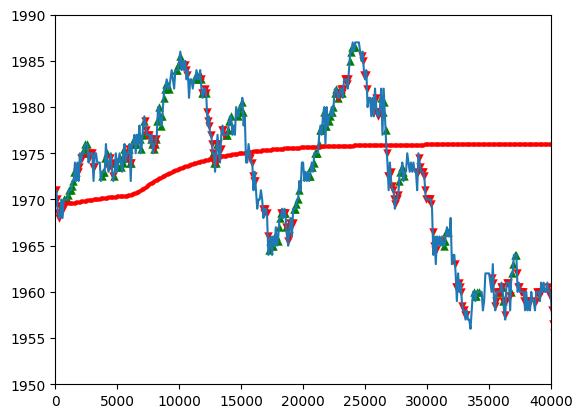

In [236]:

plt.plot(squid_ink['timestamp'],squid_ink['ask_price_1'])
plt.scatter(squid_ink['timestamp']+50,positiveTrend, color='g',marker='^',linewidths=0.05)
plt.scatter(squid_ink['timestamp']+50,negativeTrend, color='r',marker='v',linewidths=0.05)
plt.scatter(squid_ink['timestamp'],sarArray, color='r',marker='.',linewidths=0.05)
ax = plt.gca()
ax.set_xlim([0, 40000])
ax.set_ylim([1950, 1990])
plt.show()